# Set up Azure ML client

In [ ]:
from azure.ai.ml import MLClient
from azure.ai.ml.identity import AzureMLOnBehalfOfCredential

credential = AzureMLOnBehalfOfCredential()

ml_client = MLClient(
    credential,
    subscription_id="subscription_idd",
    resource_group_name="ai-300-rg",
    workspace_name="ai-300"
)

# 

In [17]:
# Get the default datastore
default_ds = ml_client.datastores.get_default()

# Enumerate all datastores and indicate which one is the default
for ds in ml_client.datastores.list():
    print(ds.name, "- Default =", ds.name == default_ds.name)

StatementMeta(f449bafc-a9ac-47e8-94a9-a0b6f513e367, 2, 32, Finished, Available, Finished, False)

_AzureMLSparkOnBehalfOfCredential.get_token succeeded


azureml_globaldatasets - Default = False
aml_datastore - Default = True
workspaceblobstore - Default = False
workspaceartifactstore - Default = False
workspaceworkingdirectory - Default = False
workspacefilestore - Default = False


In [ ]:
import requests
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes

datastore = ml_client.datastores.get_default()

datastore_path = f"azureml://datastores/{datastore.name}/paths/sales-data/"

# Register folder of CSVs as a data asset
data_asset = Data(
    path=datastore_path,
    type=AssetTypes.URI_FOLDER,
    name="sales-data",
    description="Sales CSV files",
)

ml_client.data.create_or_update(data_asset)

In [18]:
from pyspark.sql.types import *
from pyspark.sql.functions import *

df = spark.read.load(
    f"azureml://datastores/{datastore.name}/paths/sales-data/*.csv",
    format='csv',
)

display(df)
     

StatementMeta(f449bafc-a9ac-47e8-94a9-a0b6f513e367, 2, 33, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, f6fa771d-f43b-46b0-98e1-d88bcf2289d7)

In [19]:
from pyspark.sql.types import *
from pyspark.sql.functions import *

orderSchema = StructType([
    StructField("SalesOrderNumber", StringType()),
    StructField("SalesOrderLineNumber", IntegerType()),
    StructField("OrderDate", DateType()),
    StructField("CustomerName", StringType()),
    StructField("Email", StringType()),
    StructField("Item", StringType()),
    StructField("Quantity", IntegerType()),
    StructField("UnitPrice", FloatType()),
    StructField("Tax", FloatType())
])

df = spark.read.load(
    "azureml://datastores/aml_datastore/paths/sales-data/*.csv",
    format='csv',
    schema=orderSchema
)

display(df)

StatementMeta(f449bafc-a9ac-47e8-94a9-a0b6f513e367, 2, 34, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 51571c17-f149-4e35-b6c4-52241175e882)

In [20]:
df.createOrReplaceTempView("salesorders")
spark_df = spark.sql("SELECT * FROM salesorders")
display(spark_df)

StatementMeta(f449bafc-a9ac-47e8-94a9-a0b6f513e367, 2, 35, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 55f81c72-b7b6-44cb-9d21-4bb9c371615e)

In [21]:
sqlQuery = "SELECT CAST(YEAR(OrderDate) AS CHAR(4)) AS OrderYear, \
               SUM((UnitPrice * Quantity) + Tax) AS GrossRevenue \
        FROM salesorders \
        GROUP BY CAST(YEAR(OrderDate) AS CHAR(4)) \
        ORDER BY OrderYear"
df_spark = spark.sql(sqlQuery)
df_spark.show()

StatementMeta(f449bafc-a9ac-47e8-94a9-a0b6f513e367, 2, 36, Finished, Available, Finished, False)

+---------+--------------------+
|OrderYear|        GrossRevenue|
+---------+--------------------+
|     2019|   4172169.969970703|
|     2020|   6882259.268127441|
|     2021|1.1547835291696548E7|
+---------+--------------------+



StatementMeta(f449bafc-a9ac-47e8-94a9-a0b6f513e367, 2, 37, Finished, Available, Finished, False)

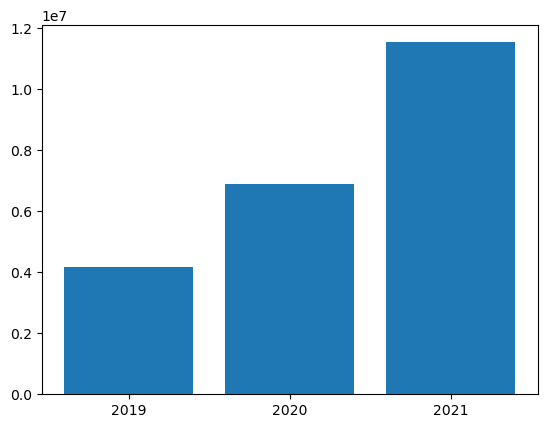

In [22]:
from matplotlib import pyplot as plt

# Convert Spark → Pandas
df_sales = df_spark.toPandas()

# Drop rows with null values
df_sales = df_sales.dropna(subset=["OrderYear", "GrossRevenue"])

# Plot
plt.bar(x=df_sales["OrderYear"], height=df_sales["GrossRevenue"])
plt.show()

StatementMeta(f449bafc-a9ac-47e8-94a9-a0b6f513e367, 2, 38, Finished, Available, Finished, False)

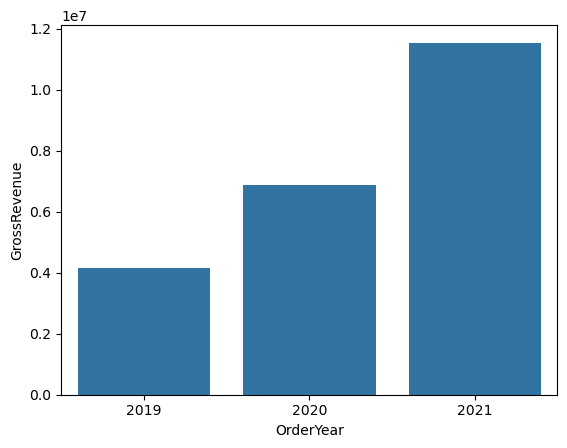

In [23]:
import seaborn as sns
from matplotlib import pyplot as plt

# Convert Spark → Pandas if not already done
df_sales = df_spark.toPandas()

# Remove rows with null values
df_sales = df_sales.dropna(subset=["OrderYear", "GrossRevenue"])

# Clear plot
plt.clf()

# Create bar chart
ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()
     